## Passara DSD, Badulla District, Sri Lanka

Reproducible pipeline: loads the ACCIMT Ditwah-Cyclone (2025) landslide inventory,
subsets the Passara study area, builds a 1 km grid, computes indicators, normalises,
aggregates into the LS-LRSI score, classifies risk, and produces all report figures.

In [20]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box

INPUT_GEOJSON = "data_raw/shp_landslides.geojson"   # place uploaded file here
STUDY_BBOX = (81.05, 6.95, 81.20, 7.10)  # lon_min, lat_min, lon_max, lat_max (Passara DSD)
CELL_SIZE_M = 1000.0
UTM_CRS = 32644  # UTM Zone 44N, appropriate for Sri Lanka

## 1. Load inventory and engineer per-polygon indicators

In [21]:
gdf = gpd.read_file(INPUT_GEOJSON)
gdf = gdf.set_crs(4326, allow_override=True)
gdf_utm = gdf.to_crs(UTM_CRS)

gdf['area_m2'] = gdf_utm.area
gdf['perimeter_m'] = gdf_utm.length
gdf['compactness'] = (4*np.pi*gdf['area_m2']) / (gdf['perimeter_m']**2)

cent_geo = gdf.geometry.to_crs(4326).centroid
gdf['lon'] = cent_geo.x
gdf['lat'] = cent_geo.y

print(f"Total landslides loaded: {len(gdf)}")
gdf[['area_m2','perimeter_m','compactness']].describe()

Total landslides loaded: 4225


C:\Users\isuru.sanjana\AppData\Local\Temp\ipykernel_31384\2627258768.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent_geo = gdf.geometry.to_crs(4326).centroid


,area_m2,perimeter_m,compactness
count,4.225000e+03,4225.000000,4225.000000
mean,7.404178e+03,455.384327,0.503560
std,2.559350e+04,675.964957,0.227552
min,5.417242e+00,11.586858,0.031363
25%,1.384455e+03,168.385488,0.322502
50%,3.044116e+03,279.122186,0.498728
75%,6.416253e+03,484.259367,0.684784
max,1.283126e+06,17103.393966,0.974468


## 2. National hotspot diagnostic (0.05° grid) — motivates Passara selection

In [22]:
gdf['lon_bin'] = (gdf['lon']//0.05)*0.05
gdf['lat_bin'] = (gdf['lat']//0.05)*0.05
hotspot = gdf.groupby(['lon_bin','lat_bin']).size().reset_index(name='count').sort_values('count', ascending=False)
hotspot.head(10)

,lon_bin,lat_bin,count
222,81.10,7.00,168
223,81.10,7.05,154
216,81.05,7.00,149
140,80.75,7.00,144
199,80.95,7.00,140
209,81.00,7.05,136
161,80.80,7.20,111
208,81.00,7.00,98
228,81.15,7.05,94
177,80.85,7.35,79


## 3. Subset the Passara study area

In [23]:
lon_min, lat_min, lon_max, lat_max = STUDY_BBOX
sub = gdf[(gdf.lon.between(lon_min, lon_max)) & (gdf.lat.between(lat_min, lat_max))].copy()
print(f"Study-area landslides: {len(sub)}")
sub_utm = sub.set_crs(4326, allow_override=True).to_crs(UTM_CRS)

Study-area landslides: 698


## 4. Build the 1 km fishnet grid and aggregate per-cell statistics

In [24]:
minx, miny, maxx, maxy = sub_utm.total_bounds
pad = 500
minx -= pad; miny -= pad; maxx += pad; maxy += pad
nx = int(np.ceil((maxx-minx)/CELL_SIZE_M))
ny = int(np.ceil((maxy-miny)/CELL_SIZE_M))

cells_list = []
for i in range(nx):
    for j in range(ny):
        x0 = minx + i*CELL_SIZE_M; y0 = miny + j*CELL_SIZE_M
        cells_list.append({'grid_id': f'{i}_{j}', 'geometry': box(x0, y0, x0+CELL_SIZE_M, y0+CELL_SIZE_M)})
grid = gpd.GeoDataFrame(cells_list, crs=UTM_CRS)
print(f"Grid cells: {len(grid)}")

joined = gpd.sjoin(sub_utm, grid, predicate='within', how='left')
agg = joined.groupby('grid_id').agg(
    n_landslides=('area_m2', 'count'),
    total_area_m2=('area_m2', 'sum'),
    mean_compactness=('compactness', 'mean')
).reset_index()
grid = grid.merge(agg, on='grid_id', how='left')
grid[['n_landslides', 'total_area_m2']] = grid[['n_landslides', 'total_area_m2']].fillna(0)
grid['mean_compactness'] = grid['mean_compactness'].fillna(grid['mean_compactness'].median())
grid['density_km2'] = grid['n_landslides'] / (CELL_SIZE_M*CELL_SIZE_M/1e6)

Grid cells: 324


## 5. Normalise indicators (HLD, MAG, CHAN)

In [25]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

grid['HLD_norm']  = minmax(grid['n_landslides'])
grid['MAG_norm']  = minmax(np.log1p(grid['total_area_m2']))
grid['CHAN_norm'] = 1 - minmax(grid['mean_compactness'])

## 6. Weighted aggregation -> LS-LRSI(3) score

LS-LRSI(3) = 100 x (0.50*HLD' + 0.30*MAG' + 0.20*CHAN')

For the full 6-indicator operational version (adds slope SL, rainfall RF, land-cover LC
once those layers are available), see the report Section 5.3 for the corresponding weights:
LS-LRSI(6) = 100 x (0.20*HLD' + 0.10*MAG' + 0.10*CHAN' + 0.25*SL' + 0.25*RF' + 0.10*LC')

In [26]:
W_HLD, W_MAG, W_CHAN = 0.50, 0.30, 0.20
grid['LS_LRSI'] = (W_HLD*grid['HLD_norm'] + W_MAG*grid['MAG_norm'] + W_CHAN*grid['CHAN_norm']) * 100

qs = grid['LS_LRSI'].quantile([0.50, 0.75, 0.90]).values
def classify(v):
    if v <= qs[0]: return 'Low'
    elif v <= qs[1]: return 'Medium'
    elif v <= qs[2]: return 'High'
    else: return 'Very High'
grid['risk_class'] = grid['LS_LRSI'].apply(classify)
grid['risk_class'].value_counts()

risk_class
Low          204
High          48
Medium        39
Very High     33
Name: count, dtype: int64

## 7. Save outputs

In [27]:
grid.to_file('./outputs/passara_grid_1km_index.geojson', driver='GeoJSON')
grid.drop(columns='geometry').to_csv('./outputs/passara_grid_1km_index.csv', index=False)
sub.to_file('./outputs/passara_landslides.geojson', driver='GeoJSON')
print('Saved outputs to ./outputs/')
grid.sort_values('LS_LRSI', ascending=False)[['grid_id','n_landslides','LS_LRSI','risk_class']].head(10)

Saved outputs to ./outputs/


,grid_id,n_landslides,LS_LRSI,risk_class
43,2_7,47.0,85.177623,Very High
168,9_6,20.0,57.162904,Very High
211,11_13,21.0,56.548618,Very High
228,12_12,17.0,53.884381,Very High
118,6_10,16.0,53.210829,Very High
227,12_11,12.0,52.916529,Very High
104,5_14,10.0,50.610854,Very High
191,10_11,11.0,50.352306,Very High
120,6_12,7.0,49.335520,Very High
119,6_11,13.0,49.141644,Very High


## 8. Figures (reproduces Figures 1-8 in the report)

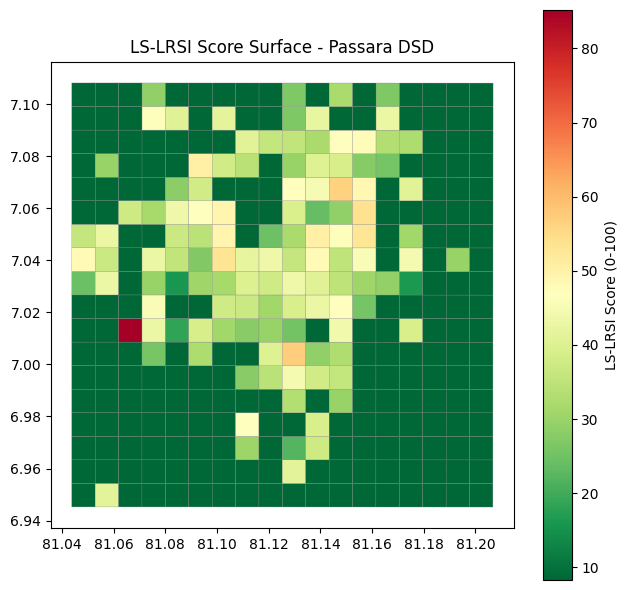

In [28]:
grid_wgs = grid.to_crs(4326)

fig, ax = plt.subplots(figsize=(6.5,6))
grid_wgs.plot(column='LS_LRSI', ax=ax, cmap='RdYlGn_r', legend=True,
              legend_kwds={'label':'LS-LRSI Score (0-100)'}, edgecolor='grey', linewidth=0.2)
ax.set_title('LS-LRSI Score Surface - Passara DSD')
plt.tight_layout(); plt.show()

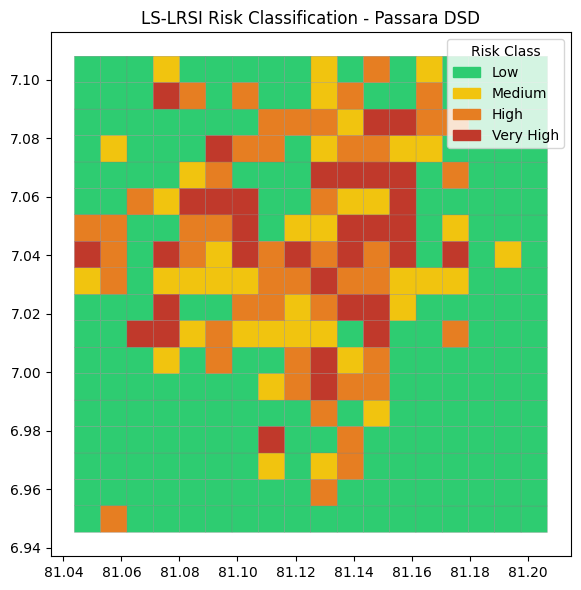

In [29]:
cls_colors = {'Low':'#2ecc71','Medium':'#f1c40f','High':'#e67e22','Very High':'#c0392b'}
fig, ax = plt.subplots(figsize=(6.5,6))
for cls, color in cls_colors.items():
    s = grid_wgs[grid_wgs.risk_class == cls]
    if len(s): s.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.2)
handles = [mpatches.Patch(color=c, label=l) for l, c in cls_colors.items()]
ax.legend(handles=handles, title='Risk Class')
ax.set_title('LS-LRSI Risk Classification - Passara DSD')
plt.tight_layout(); plt.show()